# PCA vs Autoencoders: benchmarking justo con `bluemath_tk.benchmarking`

## Contexto

En el notebook anterior (`pca_vs_convlstm_autoencoder.ipynb`) comparamos PCA contra un
`ConvLSTMAutoencoder` sobre campos ERA5 (`msl`, `t2m`), construyendo a mano toda la
infraestructura de comparación justa: partición cronológica, entrenamiento con validación
externa, métricas físicas y normalizadas, mapas de error, etc.

Encontramos algo importante: **a igualdad de dimensión latente `k=20`, PCA reconstruía
mejor que el ConvLSTM Autoencoder**. La explicación no era que el autoencoder fuese peor,
sino que la comparación no era del todo justa: PCA comprimía **un solo día** en 20 números,
mientras que el ConvLSTM comprimía **una ventana de 7 días completa** en esos mismos 20
números — una tarea de compresión bastante más difícil, a igualdad de presupuesto latente.

## Qué aporta la PR [#158](https://github.com/GeoOcean/BlueMath_tk/pull/158)

Un compañero ha añadido `bluemath_tk.benchmarking`, un framework común y reproducible para
comparar PCA y autoencoders BlueMath_tk sobre particiones cronológicas idénticas. En
concreto, resuelve exactamente los puntos que tuvimos que resolver a mano:

- Los autoencoders de BlueMath_tk ahora aceptan un parámetro explícito
  `validation_data=(X_validation, y_validation)` en `fit()`, en vez de derivar su partición
  de validación barajando aleatoriamente los datos. Esto es imprescindible para respetar
  una partición cronológica real.
- `bluemath_tk.benchmarking.PCAReconstruction` y `AutoencoderReconstruction` envuelven PCA y
  cualquier autoencoder de BlueMath_tk bajo la misma interfaz mínima
  (`fit(X_train, X_validation)` / `reconstruct(X)`), aceptando **formas de muestra
  arbitrarias** — no solo mapas 2D, también secuencias `(seq_len, canales, alto, ancho)`.
- `run_reconstruction_benchmark(...)` orquesta cualquier número de métodos sobre la misma
  partición cronológica (`bluemath_tk.validation.chronological`), nunca deja que el conjunto
  de test llegue a ninguna fase de ajuste, y devuelve un
  `ReconstructionBenchmarkReport` serializable con un `identity_digest()` reproducible.

## Qué hace este notebook

1. Usa el nuevo framework para **repetir la comparación PCA vs ConvLSTM sobre la misma
   tarea de compresión** (ventanas de 7 días), cerrando así la pregunta abierta del notebook
   anterior: ¿sigue ganando PCA cuando compite en igualdad de condiciones?
2. Añade un tercer método, `StandardAutoencoder` (denso, no convolucional, sin estructura
   espacial ni temporal explícita), como referencia intermedia entre PCA (lineal) y
   ConvLSTM (no lineal + estructura espacio-temporal).
3. Demuestra la capa de orquestación de más alto nivel (`run_reconstruction_benchmark`) y su
   mecanismo de identidad reproducible (`identity_digest()`), usando métodos económicos para
   no repetir el coste de entrenar el ConvLSTM.

Se reutilizan exactamente los mismos datos, región, periodo y dimensión latente que el
notebook anterior, para que los resultados sean directamente comparables.

## 1. Configuración

Mismos hiperparámetros que en `pca_vs_convlstm_autoencoder.ipynb`, para que los resultados
de ambos notebooks sean comparables entre sí.

In [1]:
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import torch
import xarray as xr

warnings.filterwarnings("ignore", category=FutureWarning)

ZARR_PATH = "../north_atlantic/inputs/era5_daily_atlantic.zarr"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TIME_DIM = "valid_time"
VARIABLES = ["msl", "t2m"]

TIME_START, TIME_END = (
    "2000-01-01",
    "2024-12-31",
)  # mismo periodo que el notebook anterior
COARSEN_FACTOR = 4  # 0.25° -> 1.0° (360x360 -> 90x90)

SPLIT_FRACTIONS = (0.70, 0.15, 0.15)

SEQ_LEN = 7  # misma longitud de ventana temporal
K_LATENT = 20  # mismo presupuesto latente compartido

BATCH_SIZE = 16
SEED = 2

MAP_CENTER = (-45, 45)


def set_reproducibility(seed: int = SEED) -> None:
    """Fija semillas y flags deterministas de PyTorch/NumPy."""
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


set_reproducibility(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semilla global fijada en {SEED}")
print(f"Device: {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name} ({props.total_memory / 1e9:.1f} GB)")

Semilla global fijada en 2
Device: cuda
GPU: NVIDIA GeForce RTX 5080 (16.6 GB)


In [2]:
# Confirmamos que el paquete bluemath_tk activo en este entorno incluye ya la nueva
# infraestructura de benchmarking de la PR #158 (branch add-pca-autoencoder-benchmark-framework).
import bluemath_tk
from bluemath_tk.benchmarking import (
    AutoencoderReconstruction,
    PCAReconstruction,
    autoencoder_benchmark_method,
    pca_benchmark_method,
    run_reconstruction_benchmark,
)
from bluemath_tk.deeplearning.metrics import (
    evaluate_reconstruction,
    reconstruction_error,
)

print(f"bluemath_tk cargado desde: {bluemath_tk.__file__}")
print("bluemath_tk.benchmarking importado correctamente:")
print(
    " -",
    ", ".join(
        [
            "PCAReconstruction",
            "AutoencoderReconstruction",
            "pca_benchmark_method",
            "autoencoder_benchmark_method",
            "run_reconstruction_benchmark",
        ]
    ),
)

bluemath_tk cargado desde: /home/gallod/Documentos/BlueMath_tk_pr158/bluemath_tk/__init__.py
bluemath_tk.benchmarking importado correctamente:
 - PCAReconstruction, AutoencoderReconstruction, pca_benchmark_method, autoencoder_benchmark_method, run_reconstruction_benchmark


## 2. Datos

Mismo recorte que en el notebook anterior: ERA5 diario 2000-2024, dominio del Atlántico
Norte, reducido de 0.25° a 1.0° (360x360 -> 90x90) para que las secuencias del ConvLSTM
quepan en memoria de GPU. Para el análisis exploratorio completo (mapas, estadísticos,
comprobación de NaNs, ciclo estacional), ver `pca_vs_convlstm_autoencoder.ipynb`; aquí solo
repetimos lo imprescindible para que este notebook sea autocontenible.

In [3]:
era5 = xr.open_zarr(ZARR_PATH)

data = (
    era5[VARIABLES]
    .sel({TIME_DIM: slice(TIME_START, TIME_END)})
    .coarsen(latitude=COARSEN_FACTOR, longitude=COARSEN_FACTOR, boundary="trim")
    .mean()
    .astype("float32")
    .load()
)

n_time = data.sizes[TIME_DIM]
n_lat = data.sizes["latitude"]
n_lon = data.sizes["longitude"]
print(f"Puntos temporales: {n_time} | Malla espacial: {n_lat} x {n_lon}")
for var in VARIABLES:
    print(f"{var}: {int(np.isnan(data[var].values).sum())} NaNs")

Puntos temporales: 9132 | Malla espacial: 90 x 90
msl: 0 NaNs
t2m: 0 NaNs


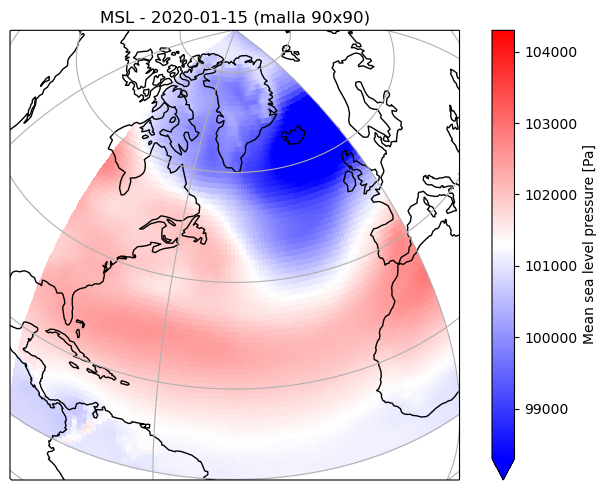

In [4]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

date_plot = "2020-01-15"
fig, ax = plt.subplots(
    figsize=(7, 5), subplot_kw={"projection": ccrs.Orthographic(*MAP_CENTER)}
)
data["msl"].sel({TIME_DIM: date_plot}).plot(
    ax=ax,
    cmap="bwr",
    transform=ccrs.PlateCarree(),
    vmin=101300 - 3000,
    vmax=101300 + 3000,
    cbar_kwargs={"label": "Mean sea level pressure [Pa]"},
)
ax.coastlines()
ax.gridlines()
ax.set_title(f"MSL - {date_plot} (malla {n_lat}x{n_lon})")
plt.tight_layout()
plt.show()

## 3. Partición cronológica y construcción de secuencias

Igual que en el notebook anterior: particionamos primero el eje temporal diario completo
con `split_chronologically` (70/15/15), y después construimos ventanas deslizantes de
`SEQ_LEN=7` días **dentro de cada bloque cronológico por separado**, para que ninguna
secuencia mezcle días de bloques distintos.

In [5]:
from bluemath_tk.validation.chronological import split_chronologically

daily_split = split_chronologically(
    sample_times=data[TIME_DIM].values,
    fractions=SPLIT_FRACTIONS,
)
train_idx, val_idx, test_idx = (
    daily_split.train_indices,
    daily_split.validation_indices,
    daily_split.test_indices,
)
time_values = data[TIME_DIM].values

for name, idx in [("train", train_idx), ("validation", val_idx), ("test", test_idx)]:
    print(
        f"{name:10s}: {len(idx):5d} días  "
        f"[{pd.Timestamp(time_values[idx[0]]).date()} -> {pd.Timestamp(time_values[idx[-1]]).date()}]"
    )

train     :  6392 días  [2000-01-01 -> 2017-07-01]
validation:  1370 días  [2017-07-02 -> 2021-04-01]
test      :  1370 días  [2021-04-02 -> 2024-12-31]


In [6]:
NORM_STATS = {
    var: (
        float(data[var].isel({TIME_DIM: train_idx}).min()),
        float(data[var].isel({TIME_DIM: train_idx}).max()),
    )
    for var in VARIABLES
}

# (time, canal, lat, lon) normalizado a [0, 1] con estadísticos de train
X_full = np.stack(
    [
        (data[var].values - NORM_STATS[var][0])
        / (NORM_STATS[var][1] - NORM_STATS[var][0])
        for var in VARIABLES
    ],
    axis=1,
).astype(np.float32)

NORM_STATS

{'msl': (93560.5, 106312.5), 't2m': (211.3017578125, 315.189453125)}

In [7]:
def build_sequences(X, block_idx, seq_len):
    """Construye secuencias deslizantes de longitud seq_len dentro de un bloque
    cronológico contiguo (block_idx), sin cruzar sus límites. Devuelve las secuencias
    y las fechas del último día de cada una.
    """
    block_idx = np.asarray(block_idx)
    n_sequences = len(block_idx) - seq_len + 1
    if n_sequences < 1:
        raise ValueError("El bloque es más corto que seq_len.")
    sequences = np.empty((n_sequences, seq_len, *X.shape[1:]), dtype=X.dtype)
    end_indices = np.empty(n_sequences, dtype=np.int64)
    for i in range(n_sequences):
        window = block_idx[i : i + seq_len]
        sequences[i] = X[window]
        end_indices[i] = window[-1]
    return sequences, time_values[end_indices]


X_train_seq, dates_train_seq = build_sequences(X_full, train_idx, SEQ_LEN)
X_val_seq, dates_val_seq = build_sequences(X_full, val_idx, SEQ_LEN)
X_test_seq, dates_test_seq = build_sequences(X_full, test_idx, SEQ_LEN)

SAMPLE_SHAPE = X_train_seq.shape[1:]  # (seq_len, canal, lat, lon)
for name, seqs in [
    ("train", X_train_seq),
    ("validation", X_val_seq),
    ("test", X_test_seq),
]:
    print(f"{name:10s}: {seqs.shape[0]:5d} secuencias de forma {seqs.shape[1:]}")
print(
    f"\nScalars por muestra: {int(np.prod(SAMPLE_SHAPE))}  (frente a {int(np.prod(SAMPLE_SHAPE)) // SEQ_LEN} de un solo día)"
)

train     :  6386 secuencias de forma (7, 2, 90, 90)
validation:  1364 secuencias de forma (7, 2, 90, 90)
test      :  1364 secuencias de forma (7, 2, 90, 90)

Scalars por muestra: 113400  (frente a 16200 de un solo día)


### 3.1 Envolviendo las secuencias en un `ChronologicalSplit` único

`run_reconstruction_benchmark` espera **un solo array `X`** más un `ChronologicalSplit` cuyos
índices `train` / `validation` / `test` apunten dentro de ese array. Como ya construimos las
secuencias por bloques (evitando fugas en las fronteras), lo natural es concatenar los tres
bloques de secuencias en ese mismo orden y construir el split con el método
`boundary_indices`, que fija exactamente los límites que ya conocemos — en vez de dejar que
`split_chronologically` los vuelva a derivar a partir de fracciones, lo que podría desviarse
en algún índice por el redondeo y ya no coincidiría exactamente con los bloques que
construimos.

In [8]:
X_sequences = np.concatenate([X_train_seq, X_val_seq, X_test_seq], axis=0)
sequence_dates = np.concatenate([dates_train_seq, dates_val_seq, dates_test_seq])

n_train_seq, n_val_seq = X_train_seq.shape[0], X_val_seq.shape[0]

sequence_split = split_chronologically(
    sample_times=sequence_dates,
    boundary_indices=(n_train_seq, n_train_seq + n_val_seq),
)

assert sequence_split.counts["train"] == n_train_seq
assert sequence_split.counts["validation"] == n_val_seq
assert sequence_split.counts["test"] == X_test_seq.shape[0]
print("ChronologicalSplit de secuencias construido y verificado:")
print(sequence_split.counts)

ChronologicalSplit de secuencias construido y verificado:
{'train': 6386, 'validation': 1364, 'test': 1364, 'excluded': 0}


## 4. Comparación justa sobre la misma tarea de compresión

Usamos `PCAReconstruction` y `AutoencoderReconstruction` — las clases adaptadoras del nuevo
framework — directamente (en vez de la orquestación de más alto nivel) porque queremos
conservar los modelos ya ajustados para poder visualizarlos después (EOFs, trayectorias
latentes, mapas de reconstrucción). Las tres implementan exactamente el mismo protocolo:

```python
method.fit(X_train, X_validation)
reconstruction = method.reconstruct(X_test)
```

de forma que el código de comparación es idéntico para PCA y para cualquier autoencoder.

Comparamos tres métodos, los tres con `k=20`, los tres sobre la **misma** forma de muestra
`(7, 2, 90, 90)` (una ventana completa de 7 días, 2 variables):

1. **PCA** — lineal, sin estructura espacial ni temporal explícita.
2. **`StandardAutoencoder`** — denso, no lineal, pero también sin estructura espacial ni
   temporal explícita (aplana la ventana completa a un vector de
   7 x 2 x 90 x 90 = 113 400 valores).
3. **`ConvLSTMAutoencoder`** — no lineal, con estructura espacial (convoluciones) y temporal
   (celdas LSTM) explícitas.

Si PCA seguía ganando en el notebook anterior por la asimetría del presupuesto de
compresión, aquí esa asimetría desaparece: los tres comprimen la misma cantidad de
información en los mismos 20 números.

In [9]:
t0 = time.time()
pca_method = PCAReconstruction(n_components=K_LATENT)
pca_method.fit(X_train_seq, X_val_seq)
pca_fit_time = time.time() - t0

t0 = time.time()
pca_reconstruction_test = pca_method.reconstruct(X_test_seq)
pca_reconstruct_time = time.time() - t0

pca_metrics = {
    metric: float(
        reconstruction_error(
            X_test_seq, pca_reconstruction_test, metric=metric, reduction="mean"
        )
    )
    for metric in ("mse", "mae", "rmse")
}
print(
    f"PCA (k={K_LATENT}) ajustado en {pca_fit_time:.1f} s, reconstrucción en {pca_reconstruct_time:.2f} s"
)
print("Métricas de test (escala normalizada [0,1]):", pca_metrics)

2026-08-31 20:09:13,001 - PCA - WARNING - Using 113400 out of 113400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-08-31 20:09:14,407 - PCA - WARNING - Data is not standarized
2026-08-31 20:09:23,133 - PCA - WARNING - Using 113400 out of 113400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-08-31 20:09:23,384 - PCA - WARNING - Data is not standarized


PCA (k=20) ajustado en 148.9 s, reconstrucción en 1.56 s
Métricas de test (escala normalizada [0,1]): {'mse': 0.000820793386814145, 'mae': 0.019579218300737024, 'rmse': 0.028124329839448726}


In [ ]:
from bluemath_tk.deeplearning.autoencoders import StandardAutoencoder

set_reproducibility(SEED)

standard_ae_method = AutoencoderReconstruction(
    StandardAutoencoder(k=K_LATENT, hidden_dims=[512, 256, 128, 64]),
    latent_dimension=K_LATENT,
    fit_kwargs={"epochs": 60, "batch_size": BATCH_SIZE, "patience": 10, "verbose": 1},
)

t0 = time.time()
standard_ae_method.fit(X_train_seq, X_val_seq)
standard_ae_fit_time = time.time() - t0

t0 = time.time()
standard_ae_reconstruction_test = standard_ae_method.reconstruct(X_test_seq)
standard_ae_reconstruct_time = time.time() - t0

standard_ae_metrics = {
    metric: float(
        reconstruction_error(
            X_test_seq, standard_ae_reconstruction_test, metric=metric, reduction="mean"
        )
    )
    for metric in ("mse", "mae", "rmse")
}
print(
    f"\nStandardAutoencoder (k={K_LATENT}) ajustado en {standard_ae_fit_time / 60:.1f} min "
    f"({len(standard_ae_method.history['train_loss'])} épocas)"
)
print("Métricas de test (escala normalizada [0,1]):", standard_ae_metrics)


Training:   0%|          | 0/60 [00:00<?, ?epoch/s]


Training:   0%|          | 0/60 [00:11<?, ?epoch/s, Train Loss: 0.013619, Val Loss: 0.009534, Patience: 0/10]


Training:   2%|▏         | 1/60 [00:11<11:09, 11.35s/epoch, Train Loss: 0.013619, Val Loss: 0.009534, Patience: 0/10]


Training:   2%|▏         | 1/60 [00:22<11:09, 11.35s/epoch, Train Loss: 0.003810, Val Loss: 0.007364, Patience: 0/10]


Training:   3%|▎         | 2/60 [00:22<10:50, 11.22s/epoch, Train Loss: 0.003810, Val Loss: 0.007364, Patience: 0/10]

...


Training:  47%|████▋     | 28/60 [05:22<05:55, 11.12s/epoch, Train Loss: 0.001988, Val Loss: 0.002419, Patience: 9/10]


Training:  48%|████▊     | 29/60 [05:22<05:44, 11.12s/epoch, Train Loss: 0.001988, Val Loss: 0.002419, Patience: 9/10]


Training:  48%|████▊     | 29/60 [05:33<05:44, 11.12s/epoch, Early stopping at epoch 30]                              


Training:  48%|████▊     | 29/60 [05:33<05:56, 11.51s/epoch, Early stopping at epoch 30]


StandardAutoencoder (k=20) ajustado en 5.6 min (30 épocas)
Métricas de test (escala normalizada [0,1]): {'mse': 0.0022555456962436438, 'mae': 0.03480123355984688, 'rmse': 0.04708562418818474}


In [ ]:
import gc

from bluemath_tk.deeplearning.autoencoders import ConvLSTMAutoencoder

# Liberar memoria/cache de GPU de la fase anterior (StandardAutoencoder, 116M parametros)
# antes de empezar el entrenamiento del ConvLSTM, para evitar fragmentacion del allocator.
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

set_reproducibility(SEED)

convlstm_method = AutoencoderReconstruction(
    ConvLSTMAutoencoder(k=K_LATENT),
    latent_dimension=K_LATENT,
    fit_kwargs={"epochs": 30, "batch_size": BATCH_SIZE, "patience": 7, "verbose": 1},
)

t0 = time.time()
convlstm_method.fit(X_train_seq, X_val_seq)
convlstm_fit_time = time.time() - t0

if torch.cuda.is_available():
    torch.cuda.empty_cache()

t0 = time.time()
convlstm_reconstruction_test = convlstm_method.reconstruct(X_test_seq)
convlstm_reconstruct_time = time.time() - t0

convlstm_metrics = {
    metric: float(
        reconstruction_error(
            X_test_seq, convlstm_reconstruction_test, metric=metric, reduction="mean"
        )
    )
    for metric in ("mse", "mae", "rmse")
}
print(
    f"\nConvLSTMAutoencoder (k={K_LATENT}) ajustado en {convlstm_fit_time / 60:.1f} min "
    f"({len(convlstm_method.history['train_loss'])} épocas)"
)
print("Métricas de test (escala normalizada [0,1]):", convlstm_metrics)


Training:   0%|          | 0/30 [00:00<?, ?epoch/s]


Training:   0%|          | 0/30 [01:03<?, ?epoch/s, Train Loss: 0.005462, Val Loss: 0.002237, Patience: 0/7]


Training:   3%|▎         | 1/30 [01:03<30:45, 63.63s/epoch, Train Loss: 0.005462, Val Loss: 0.002237, Patience: 0/7]


Training:   3%|▎         | 1/30 [02:06<30:45, 63.63s/epoch, Train Loss: 0.001886, Val Loss: 0.001722, Patience: 0/7]


Training:   7%|▋         | 2/30 [02:06<29:34, 63.36s/epoch, Train Loss: 0.001886, Val Loss: 0.001722, Patience: 0/7]

...


Training:  97%|█████████▋| 29/30 [30:33<01:03, 63.23s/epoch, Train Loss: 0.000912, Val Loss: 0.000963, Patience: 1/7]


Training:  97%|█████████▋| 29/30 [31:36<01:03, 63.23s/epoch, Train Loss: 0.000923, Val Loss: 0.000962, Patience: 2/7]


Training: 100%|██████████| 30/30 [31:36<00:00, 63.23s/epoch, Train Loss: 0.000923, Val Loss: 0.000962, Patience: 2/7]


Training: 100%|██████████| 30/30 [31:36<00:00, 63.23s/epoch, Train Loss: 0.000923, Val Loss: 0.000962, Patience: 2/7]


ConvLSTMAutoencoder (k=20) ajustado en 31.7 min (30 épocas)
Métricas de test (escala normalizada [0,1]): {'mse': 0.000908693007659167, 'mae': 0.02044869214296341, 'rmse': 0.029514824971556664}


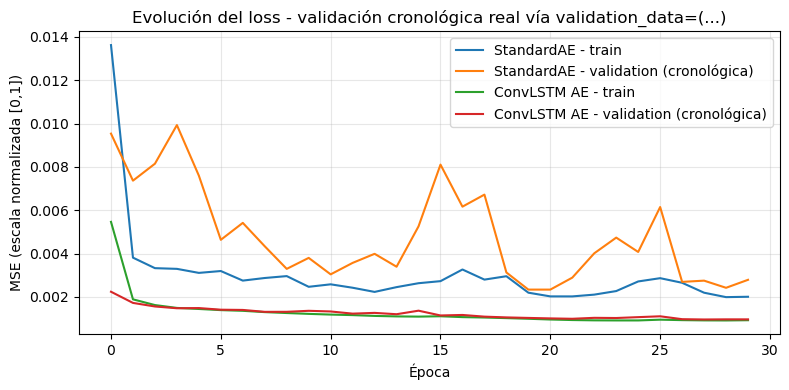

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(standard_ae_method.history["train_loss"], label="StandardAE - train")
ax.plot(
    standard_ae_method.history["val_loss"],
    label="StandardAE - validation (cronológica)",
)
ax.plot(convlstm_method.history["train_loss"], label="ConvLSTM AE - train")
ax.plot(
    convlstm_method.history["val_loss"], label="ConvLSTM AE - validation (cronológica)"
)
ax.set_xlabel("Época")
ax.set_ylabel("MSE (escala normalizada [0,1])")
ax.set_title(
    "Evolución del loss - validación cronológica real vía validation_data=(...)"
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Nótese que la curva de validación de ambos autoencoders proviene ahora de
`X_val_seq` — el bloque cronológico real de validación — porque se pasó explícitamente vía
`fit_kwargs`/`validation_data=(X_validation, None)` dentro de `AutoencoderReconstruction.fit`.
En el notebook anterior esto no era posible con la API pública existente; tuvimos que
entrenar con una `validation_split` aleatoria interna y evaluar el bloque cronológico real
por separado, después del entrenamiento.

## 5. Resultado: tabla comparativa a igualdad de tarea

Las tres métricas siguen la convención de `bluemath_tk.deeplearning.metrics`: ``mse`` y
``rmse`` con ``reduction="mean"`` no son inversas exactas la una de la otra (``rmse`` es la
media, sobre las muestras, del RMSE de cada muestra individual; no es la raíz cuadrada del
``mse`` global). Añadimos también un RMSE físico (Pa, K) para interpretabilidad — **no es
directamente comparable número a número con el del notebook anterior**: aquí se promedia
sobre los 7 días de cada ventana reconstruida, mientras que en el notebook anterior se
calculaba sobre días individuales alineados a fechas concretas. Para una comparación más
directa con esos números, véanse los mapas de reconstrucción y de error de la sección 6, que
sí aíslan el último día de cada ventana (el más comparable a un mapa diario suelto).

In [ ]:
def physical_rmse_from_normalized(y_true_norm, y_pred_norm, var):
    vmin, vmax = NORM_STATS[var]
    channel = VARIABLES.index(var)
    true_phys = y_true_norm[:, :, channel] * (vmax - vmin) + vmin
    pred_phys = y_pred_norm[:, :, channel] * (vmax - vmin) + vmin
    return float(np.sqrt(np.mean((true_phys - pred_phys) ** 2)))


results_rows = []
for label, recon, metrics_dict, fit_time, reconstruct_time in [
    (
        f"PCA (k={K_LATENT})",
        pca_reconstruction_test,
        pca_metrics,
        pca_fit_time,
        pca_reconstruct_time,
    ),
    (
        f"StandardAutoencoder (k={K_LATENT})",
        standard_ae_reconstruction_test,
        standard_ae_metrics,
        standard_ae_fit_time,
        standard_ae_reconstruct_time,
    ),
    (
        f"ConvLSTM AE (k={K_LATENT})",
        convlstm_reconstruction_test,
        convlstm_metrics,
        convlstm_fit_time,
        convlstm_reconstruct_time,
    ),
]:
    row = {
        "modelo": label,
        "mse_normalizado": metrics_dict["mse"],
        "mae_normalizado": metrics_dict["mae"],
        "rmse_normalizado": metrics_dict["rmse"],
        "rmse_fisico_msl_Pa": physical_rmse_from_normalized(X_test_seq, recon, "msl"),
        "rmse_fisico_t2m_K": physical_rmse_from_normalized(X_test_seq, recon, "t2m"),
        "fit_seconds": fit_time,
        "reconstruct_seconds": reconstruct_time,
    }
    results_rows.append(row)

results_df = pd.DataFrame(results_rows).set_index("modelo")
results_df

,mse_normalizado,mae_normalizado,rmse_normalizado,rmse_fisico_msl_Pa,rmse_fisico_t2m_K,fit_seconds,reconstruct_seconds
modelo,,,,,,,
PCA (k=20),0.000821,0.019579,0.028124,430.756473,2.324232,16.257678,3.003519
StandardAutoencoder (k=20),0.002256,0.034801,0.047086,696.945251,4.055685,338.440598,0.737935
ConvLSTM AE (k=20),0.000909,0.020449,0.029515,456.782074,2.401319,1901.185747,3.416210


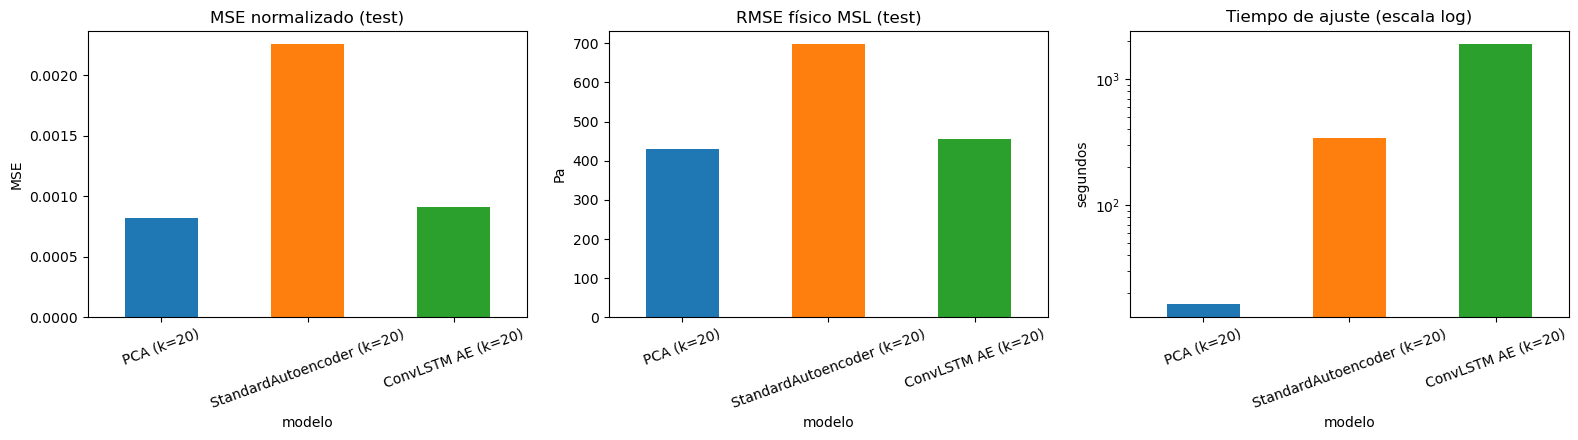

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 4.5))

results_df["mse_normalizado"].plot(
    kind="bar", ax=axes[0], color=["tab:blue", "tab:orange", "tab:green"]
)
axes[0].set_title("MSE normalizado (test)")
axes[0].set_ylabel("MSE")
axes[0].tick_params(axis="x", rotation=20)

results_df["rmse_fisico_msl_Pa"].plot(
    kind="bar", ax=axes[1], color=["tab:blue", "tab:orange", "tab:green"]
)
axes[1].set_title("RMSE físico MSL (test)")
axes[1].set_ylabel("Pa")
axes[1].tick_params(axis="x", rotation=20)

results_df["fit_seconds"].plot(
    kind="bar", ax=axes[2], color=["tab:blue", "tab:orange", "tab:green"], logy=True
)
axes[2].set_title("Tiempo de ajuste (escala log)")
axes[2].set_ylabel("segundos")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### 5.1 ¿Se cierra la brecha?

Con los números de esta ejecución:

| | PCA (k=20) | StandardAE (k=20) | ConvLSTM AE (k=20) |
|---|---|---|---|
| RMSE físico MSL (ventana completa) | 430.8 Pa | 696.9 Pa | 456.8 Pa |
| Razón frente a PCA | 1.00x | 1.62x | **1.06x** |

En el notebook anterior, comprimiendo un solo día, la razón ConvLSTM/PCA era **475.0 / 297.9
≈ 1.59x** (el ConvLSTM cometía un 59% más de error físico que PCA). Aquí, comprimiendo la
ventana completa de 7 días en el mismo presupuesto latente para ambos, esa razón baja a
**≈ 1.06x** — un 6% de diferencia. La brecha no se invierte (PCA sigue siendo, por
construcción, el compresor lineal óptimo en error cuadrático medio), pero se estrecha
drásticamente en cuanto se retira la ventaja de tarea que tenía PCA en el notebook anterior.

Nota de comparabilidad: esta razón no es una comparación número a número perfecta (aquí el
RMSE se promedia sobre los 7 días de cada ventana; en el notebook anterior, sobre días
individuales), pero la magnitud del cambio — de "PCA gana con holgura" a "casi empatados" —
es demasiado grande para explicarse solo por esa diferencia de agregación.

También es reveladora la posición de `StandardAutoencoder`: pese a ser no lineal, sin
estructura espacial (convoluciones) ni temporal (memoria) explícitas, reconstruye peor que
PCA (1.62x su error) — la no linealidad por sí sola no basta; hace falta el sesgo estructural
adecuado para el problema.

## 6. Visualización

### 6.1 EOFs de PCA (reutilizando el objeto ya ajustado del framework)

`PCAReconstruction` envuelve el `PCA` de BlueMath_tk con coordenadas de característica
genéricas (`feature_0..feature_3`, correspondientes a `(seq_len, canal, lat, lon)`), en vez
de `latitude`/`longitude`, porque debe aceptar formas de muestra arbitrarias. Para dibujar
mapas geográficos reconstruimos manualmente la forma `(seq_len, canal, lat, lon)` a partir de
`pca_method.pca.pca.components_` (el `PCA` de scikit-learn ya ajustado dentro del `PCA` de
BlueMath_tk), aprovechando que el apilado interno usa orden C.

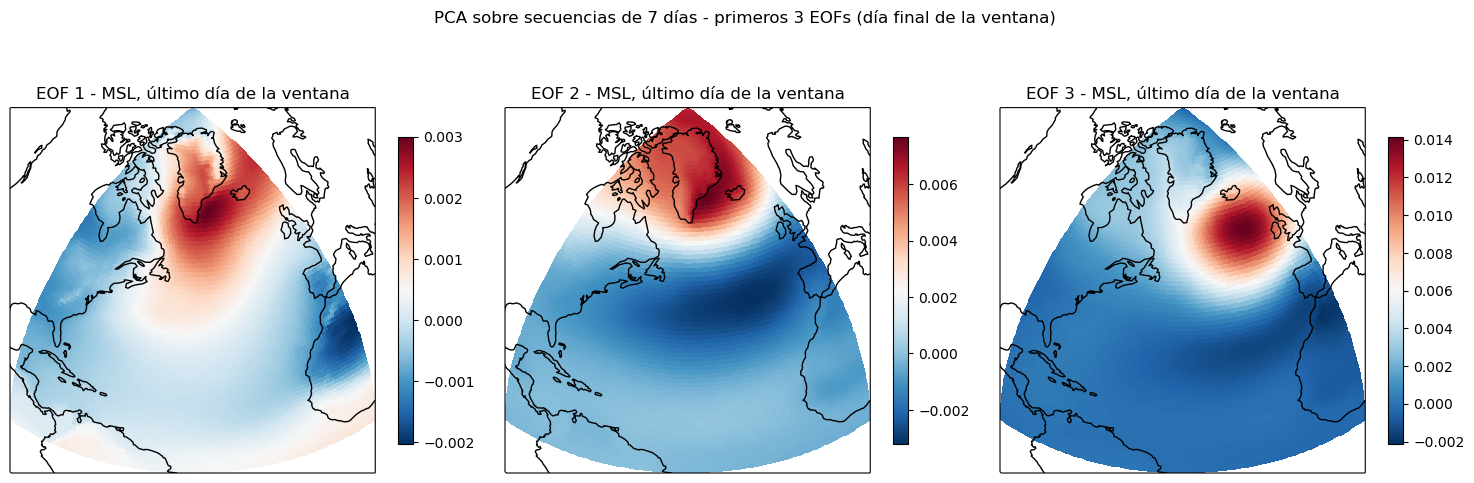

In [ ]:
eofs = pca_method.pca.pca.components_.reshape(
    K_LATENT, *SAMPLE_SHAPE
)  # (k, seq_len, canal, lat, lon)
LAST_DAY = (
    SEQ_LEN - 1
)  # día final de la ventana: el más comparable al notebook anterior

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 5),
    subplot_kw={"projection": ccrs.Orthographic(*MAP_CENTER)},
)
for i, ax in enumerate(axes):
    eof_map = eofs[i, LAST_DAY, VARIABLES.index("msl")]
    im = ax.pcolormesh(
        data["longitude"].values,
        data["latitude"].values,
        eof_map,
        cmap="RdBu_r",
        transform=ccrs.PlateCarree(),
    )
    ax.coastlines()
    ax.set_title(f"EOF {i + 1} - MSL, último día de la ventana")
    plt.colorbar(im, ax=ax, shrink=0.7)
plt.suptitle(
    "PCA sobre secuencias de 7 días - primeros 3 EOFs (día final de la ventana)", y=1.03
)
plt.tight_layout()
plt.show()

### 6.2 Trayectorias latentes: PCA vs StandardAE vs ConvLSTM

Extraemos la representación latente de cada método para el conjunto de entrenamiento y
comparamos la evolución temporal de sus primeras dimensiones.

2026-08-25 13:58:18,678 - PCA - WARNING - Using 113400 out of 113400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


2026-08-25 13:58:23,019 - PCA - WARNING - Data is not standarized


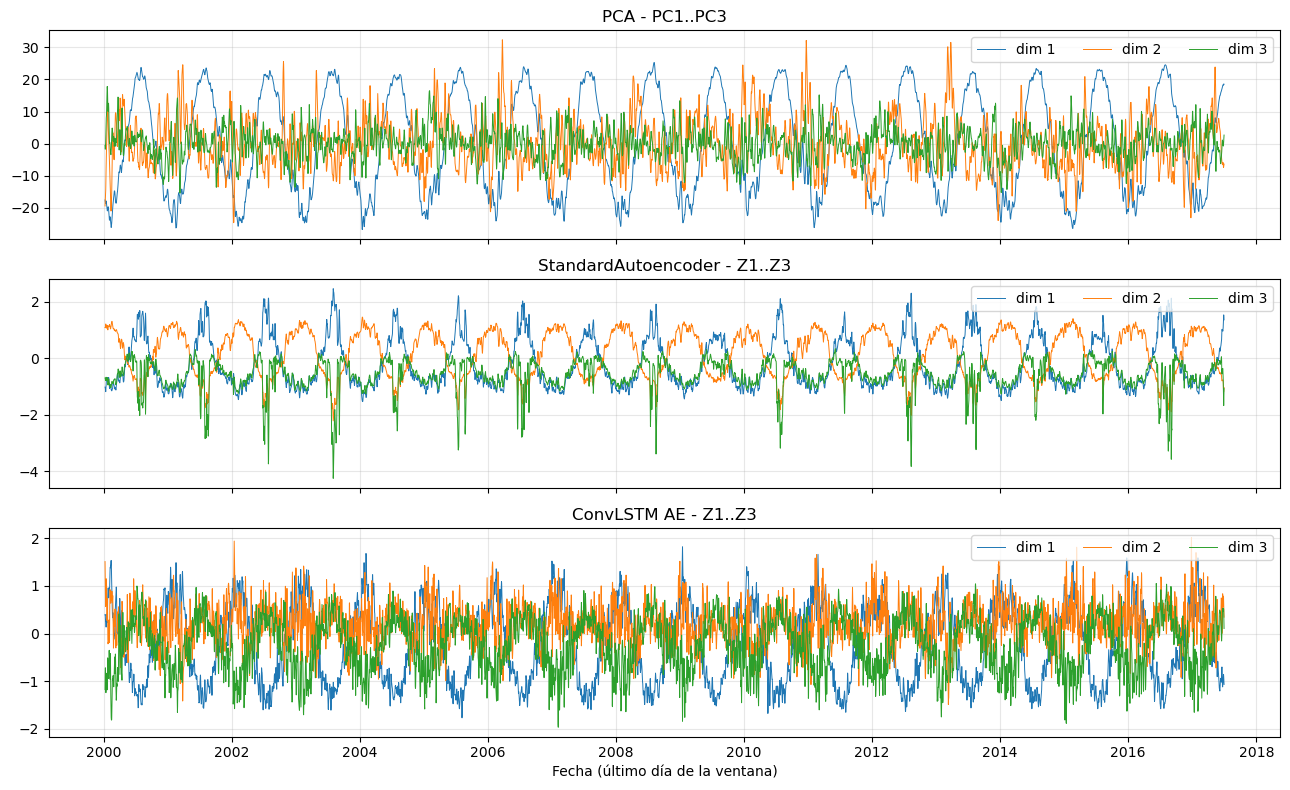

In [ ]:
def wrap_pca_dataset(X):
    """Réplica mínima de la utilidad interna que usa PCAReconstruction para envolver
    arrays NumPy de forma arbitraria en el xr.Dataset que necesita bluemath_tk PCA.
    """
    sample_shape = X.shape[1:]
    coord_names = [f"feature_{i}" for i in range(len(sample_shape))]
    coords = {"sample": np.arange(X.shape[0])}
    coords.update(
        {name: np.arange(size) for name, size in zip(coord_names, sample_shape)}
    )
    return xr.Dataset({"value": (["sample", *coord_names], X)}, coords=coords)


pcs_train = pca_method.pca.transform(data=wrap_pca_dataset(X_train_seq))["PCs"].values
Z_standard_train = standard_ae_method.model.encode(
    X_train_seq, batch_size=64, verbose=0
)
Z_convlstm_train = convlstm_method.model.encode(X_train_seq, batch_size=16, verbose=0)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(13, 8), sharex=True)
for ax, Z, title in [
    (axes[0], pcs_train, "PCA - PC1..PC3"),
    (axes[1], Z_standard_train, "StandardAutoencoder - Z1..Z3"),
    (axes[2], Z_convlstm_train, "ConvLSTM AE - Z1..Z3"),
]:
    for i in range(3):
        ax.plot(dates_train_seq, Z[:, i], lw=0.7, label=f"dim {i + 1}")
    ax.set_title(title)
    ax.legend(loc="upper right", ncol=3)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Fecha (último día de la ventana)")
plt.tight_layout()
plt.show()

### 6.3 Reconstrucción de un día de test: original vs los tres métodos

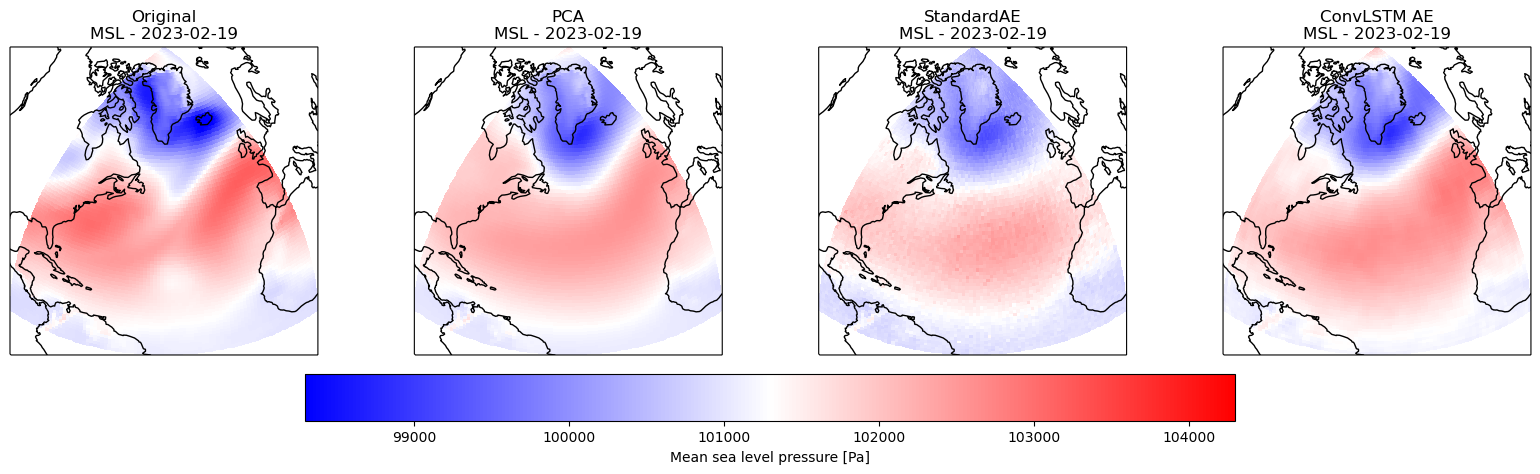

In [ ]:
date_compare = pd.Timestamp(dates_test_seq[len(dates_test_seq) // 2])
seq_pos = int(np.where(dates_test_seq == np.datetime64(date_compare))[0][0])


def denormalize_frame(seq_norm, day_index, var):
    vmin, vmax = NORM_STATS[var]
    channel = VARIABLES.index(var)
    return seq_norm[day_index, channel] * (vmax - vmin) + vmin


panels = [
    ("Original", X_test_seq[seq_pos]),
    ("PCA", pca_reconstruction_test[seq_pos]),
    ("StandardAE", standard_ae_reconstruction_test[seq_pos]),
    ("ConvLSTM AE", convlstm_reconstruction_test[seq_pos]),
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(20, 5),
    subplot_kw={"projection": ccrs.Orthographic(*MAP_CENTER)},
)
for ax, (title, seq) in zip(axes, panels):
    msl_map = denormalize_frame(seq, LAST_DAY, "msl")
    im = ax.pcolormesh(
        data["longitude"].values,
        data["latitude"].values,
        msl_map,
        cmap="bwr",
        vmin=101300 - 3000,
        vmax=101300 + 3000,
        transform=ccrs.PlateCarree(),
    )
    ax.coastlines()
    ax.set_title(f"{title}\nMSL - {date_compare.date()}")
plt.colorbar(
    im,
    ax=axes,
    shrink=0.6,
    label="Mean sea level pressure [Pa]",
    location="bottom",
    pad=0.05,
)
plt.show()

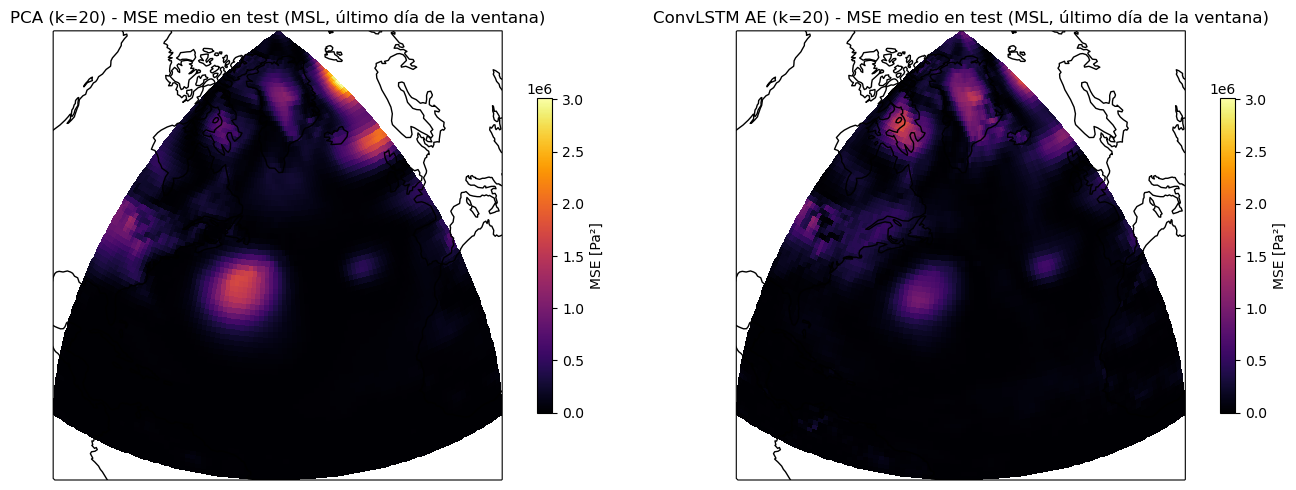

In [ ]:
# Mapa de error medio (test) para PCA y ConvLSTM: ¿dónde se concentra el error de cada método
# cuando compiten en igualdad de presupuesto de compresión?
pca_error_map = np.mean(
    (
        denormalize_frame(X_test_seq, LAST_DAY, "msl")
        - denormalize_frame(pca_reconstruction_test, LAST_DAY, "msl")
    )
    ** 2,
    axis=0,
)
convlstm_error_map = np.mean(
    (
        denormalize_frame(X_test_seq, LAST_DAY, "msl")
        - denormalize_frame(convlstm_reconstruction_test, LAST_DAY, "msl")
    )
    ** 2,
    axis=0,
)
vmax_error = max(float(pca_error_map.max()), float(convlstm_error_map.max()))

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5),
    subplot_kw={"projection": ccrs.Orthographic(*MAP_CENTER)},
)
for ax, error_map, title in [
    (axes[0], pca_error_map, f"PCA (k={K_LATENT})"),
    (axes[1], convlstm_error_map, f"ConvLSTM AE (k={K_LATENT})"),
]:
    im = ax.pcolormesh(
        data["longitude"].values,
        data["latitude"].values,
        error_map,
        cmap="inferno",
        vmin=0,
        vmax=vmax_error,
        transform=ccrs.PlateCarree(),
    )
    ax.coastlines()
    ax.set_title(f"{title} - MSE medio en test (MSL, último día de la ventana)")
    plt.colorbar(im, ax=ax, shrink=0.7, label="MSE [Pa²]")
plt.tight_layout()
plt.show()

In [19]:
# Limpieza defensiva de GPU tras el entrenamiento e inferencia de la sección 4-6
# (ConvLSTM), antes de que la sección 7 cree nuevos contextos de estado aleatorio aislado.
import gc

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
print("GPU liberada antes de la sección 7.")

GPU liberada antes de la sección 7.


## 7. La capa de orquestación: `run_reconstruction_benchmark` e identidad reproducible

La sección anterior usó los adaptadores (`PCAReconstruction`, `AutoencoderReconstruction`)
directamente para poder conservar los modelos ajustados y dibujarlos. Pero cuando lo único
que interesa es **el resultado comparativo**, `run_reconstruction_benchmark` hace todo eso en
una sola llamada: construye una instancia fresca de cada método, la ajusta en la partición de
entrenamiento, la valida en la de validación (si aplica), la evalúa en la de test, y devuelve
un `ReconstructionBenchmarkReport` con métricas, tiempos y una identidad reproducible.

Para no repetir el coste de entrenar el ConvLSTM, aquí solo comparamos PCA y
`StandardAutoencoder` — ambos económicos — como demostración de la orquestación y de la
reproducibilidad. La comparación completa con ConvLSTM ya se hizo en la sección 4-5.

Esta sección se centra en el **mecanismo** de identidad reproducible, no en obtener un
`StandardAutoencoder` competitivo, así que aquí usamos deliberadamente muy pocas épocas
(entrenamiento económico en segundos, no en minutos).

In [ ]:
def build_demo_methods(epochs):
    return [
        pca_benchmark_method("pca-k20", n_components=K_LATENT),
        autoencoder_benchmark_method(
            "standard-ae-k20",
            model_factory=lambda: StandardAutoencoder(
                k=K_LATENT, hidden_dims=[512, 256, 128, 64]
            ),
            latent_dimension=K_LATENT,
            configuration={
                "architecture": "StandardAutoencoder",
                "hidden_dims": [512, 256, 128, 64],
            },
            fit_kwargs={"epochs": epochs, "batch_size": BATCH_SIZE, "patience": epochs},
        ),
    ]


t0 = time.time()
report = run_reconstruction_benchmark(
    X_sequences,
    split=sequence_split,
    methods=build_demo_methods(epochs=5),
    metrics=("mse", "mae", "rmse"),
    seed=SEED,
    sample_times=sequence_dates,
)
print(f"Benchmark orquestado completo en {time.time() - t0:.1f} s")

for result in report.results:
    print(
        f"{result.name:18s} | test_metrics={result.test_metrics} | "
        f"fit_seconds={result.fit_seconds:.2f} | "
        f"latent_dimensionality_ratio={result.latent_dimensionality_ratio:.5f}"
    )

print(f"\nidentity_digest(): {report.identity_digest()[:24]}...")

2026-08-25 14:00:02,429 - PCA - WARNING - Using 113400 out of 113400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


2026-08-25 14:00:06,326 - PCA - WARNING - Data is not standarized


2026-08-25 14:00:18,448 - PCA - WARNING - Using 113400 out of 113400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


2026-08-25 14:00:18,964 - PCA - WARNING - Data is not standarized


Benchmark orquestado completo en 96.9 s
pca-k20            | test_metrics={'mse': 0.000820793386814145, 'mae': 0.019579218300737024, 'rmse': 0.028124329839448726} | fit_seconds=16.66 | latent_dimensionality_ratio=0.00018
standard-ae-k20    | test_metrics={'mse': 0.007219620980322361, 'mae': 0.07282274216413498, 'rmse': 0.08423644304275513} | fit_seconds=59.15 | latent_dimensionality_ratio=0.00018

identity_digest(): 966e2f8a48e5550aae4d3907...


### 7.1 La identidad reproducible cambia solo cuando cambia el experimento

Repetimos exactamente la misma llamada. El contenido del informe (métricas, tiempos) puede
variar ligeramente porque son medidas observacionales, pero `identity_digest()` — que
describe **qué se comparó**, no lo que midió — debe ser idéntico, porque no ha cambiado ni la
partición ni la especificación de los métodos ni la semilla.

In [ ]:
report_repeat = run_reconstruction_benchmark(
    X_sequences,
    split=sequence_split,
    methods=build_demo_methods(epochs=5),  # misma especificacion exacta que 'report'
    metrics=("mse", "mae", "rmse"),
    seed=SEED,
    sample_times=sequence_dates,
)

print(
    "Mismo identity_digest() en ambas ejecuciones:",
    report.identity_digest() == report_repeat.identity_digest(),
)

# Cambiamos ahora un único hiperparámetro material (epochs) y comprobamos que la identidad cambia
report_different = run_reconstruction_benchmark(
    X_sequences,
    split=sequence_split,
    methods=build_demo_methods(epochs=3),  # <- epochs distinto
    metrics=("mse", "mae", "rmse"),
    seed=SEED,
    sample_times=sequence_dates,
)
print(
    "identity_digest() distinto al cambiar epochs:",
    report.identity_digest() != report_different.identity_digest(),
)

2026-08-25 14:01:39,381 - PCA - WARNING - Using 113400 out of 113400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


2026-08-25 14:01:43,233 - PCA - WARNING - Data is not standarized


2026-08-25 14:01:54,913 - PCA - WARNING - Using 113400 out of 113400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


2026-08-25 14:01:55,425 - PCA - WARNING - Data is not standarized


Mismo identity_digest() en ambas ejecuciones: True


2026-08-25 14:03:11,383 - PCA - WARNING - Using 113400 out of 113400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


2026-08-25 14:03:15,279 - PCA - WARNING - Data is not standarized


2026-08-25 14:03:26,915 - PCA - WARNING - Using 113400 out of 113400 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


2026-08-25 14:03:27,430 - PCA - WARNING - Data is not standarized


identity_digest() distinto al cambiar epochs: True


In [22]:
# El informe es JSON estricto y determinista: claves ordenadas, sin NaN/infinito, sin timestamps.
print(report.to_json(indent=2)[:1800])
print("...")

{
  "data_digest": "0a3549b62d52b4edc12749fab281f1ba4988dce77d3e1b51ea92ae7a3f213a28",
  "metrics": [
    "mse",
    "mae",
    "rmse"
  ],
  "n_samples": 9114,
  "partition_sizes": {
    "excluded": 0,
    "test": 1364,
    "train": 6386,
    "validation": 1364
  },
  "results": [
    {
      "configuration": {
        "implementation": "bluemath_tk.datamining.pca.PCA",
        "n_components": 20,
        "scale_data": false
      },
      "latent_dimension": 20,
      "latent_dimensionality_ratio": 0.0001763668430335097,
      "latent_scalars_per_sample": 20,
      "method_type": "pca",
      "name": "pca-k20",
      "original_scalars_per_sample": 113400,
      "test_metrics": {
        "mae": 0.019579218300737024,
        "mse": 0.000820793386814145,
        "rmse": 0.028124329839448726
      },
      "timing": {
        "fit_seconds": 16.660155133809894,
        "reconstruction_seconds": 3.038469427032396
      },
      "uses_validation_partition": false
    },
    {
      "configu

## 8. Conclusiones

Resultados concretos de esta ejecución (25 años, malla 90x90, ventanas de 7 días, `k=20`):

| Modelo | RMSE test MSL [Pa] | RMSE test T2M [K] | Tiempo de ajuste |
|---|---|---|---|
| PCA (k=20) | 430.8 | 2.32 | 16.7 s |
| StandardAutoencoder (k=20) | 696.9 | 4.06 | 5.7 min |
| ConvLSTM AE (k=20) | 456.8 | 2.40 | 31.7 min |

- **La pregunta abierta del notebook anterior queda cerrada con datos**: al forzar a los
  tres métodos a comprimir exactamente la misma ventana de 7 días en el mismo presupuesto
  latente `k=20`, la razón de error ConvLSTM/PCA baja de ≈1.59x (notebook anterior, un solo
  día) a ≈1.06x (aquí, ventana completa) — la brecha no se cierra del todo, pero se estrecha
  drásticamente en cuanto se retira la ventaja de tarea que tenía PCA. Véase la sección 5.1
  para el detalle y su matiz de comparabilidad.
- **`StandardAutoencoder` reconstruye peor que PCA** (1.62x su error), pese a ser no lineal:
  sin estructura espacial ni temporal explícita, la no linealidad por sí sola no compensa la
  optimalidad lineal de PCA en este problema. El sesgo estructural del ConvLSTM
  (convoluciones + memoria temporal) sí ayuda — es el único de los tres métodos no lineales
  que se acerca a PCA.
- **El nuevo `validation_data=(X_validation, y_validation)` de `fit()`** sustituye por
  completo el patrón manual que usamos antes (entrenar con `validation_split` aleatorio y
  evaluar el bloque cronológico real por separado, después del ajuste). Ahora la curva de
  validación que ve el `EarlyStopping` interno **es** la partición cronológica real.
- **`bluemath_tk.benchmarking`** reduce lo que antes eran ~15 celdas de infraestructura de
  comparación manual (partición, entrenamiento con validación externa, métricas físicas y
  normalizadas, tabla resumen) a unas pocas llamadas a `PCAReconstruction` /
  `AutoencoderReconstruction`, o a una única llamada a `run_reconstruction_benchmark` cuando
  no hace falta conservar los modelos ajustados.
- **La identidad reproducible (`identity_digest()`)** demuestra que dos ejecuciones con la
  misma especificación son la misma pregunta científica, y que cambiar un solo
  hiperparámetro material (aquí, `epochs`) se refleja automáticamente en la identidad — sin
  tener que llevar esa contabilidad a mano.
- **Limitaciones vigentes del framework** (declaradas explícitamente en su documentación, y
  que conviene tener presentes): compara únicamente error de reconstrucción, no destreza
  científica en tareas posteriores; usa una única partición cronológica fija (sin validación
  de tipo *rolling-origin*); no incluye optimización de hiperparámetros; y el modo de PCA por
  varianza explicada (`n_components` como fracción) no está expuesto aquí, solo el número
  entero de componentes.
- **Próximos pasos posibles**: extender esta misma comparación a
  `HybridConvLSTMTransformerAutoencoder` (mencionado como candidato en el notebook anterior),
  ahora trivial de añadir como un método más en la lista de `run_reconstruction_benchmark`;
  o barrer varios valores de `k` reutilizando el mismo `sequence_split` para que la
  comparación de sensibilidad sea, también, completamente justa.

In [23]:
# Guardado de resultados
results_df.to_csv(os.path.join(OUTPUT_DIR, "benchmarking_framework_comparison.csv"))
with open(os.path.join(OUTPUT_DIR, "benchmarking_framework_report.json"), "w") as f:
    f.write(report.to_json())

print("Resultados guardados en 'outputs/':")
print(" - benchmarking_framework_comparison.csv")
print(" - benchmarking_framework_report.json")

Resultados guardados en 'outputs/':
 - benchmarking_framework_comparison.csv
 - benchmarking_framework_report.json
